In [1]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d
from astropy.coordinates import SkyCoord
from matplotlib.patches import ConnectionPatch
import os,cv2
from scipy.optimize import fmin
from scipy.ndimage import affine_transform
import shutil
from scipy.io import readsav
import glob
from matplotlib.patches import Rectangle
from scipy.ndimage import zoom

In [2]:
q=readsav(r'D:\Learning\PHD1st\magnetic_reconnecion\data\QSL\qfactor\q3d_delta0.25.sav')

c:\Users\19671\anaconda3\envs\sun\Lib\site-packages\scipy\io\_idl.py:339: UserWarning: Using experimental 64-bit array read
  rectypedesc = _read_typedesc(f)


In [4]:
q3d=q['q3d']
q3d=q3d.transpose(2,1,0)

In [6]:
from scipy.interpolate import RegularGridInterpolator
interp_q=RegularGridInterpolator((np.arange(1437),np.arange(1117),np.arange(1117)),q3d)

In [7]:
print(interp_q([10,10,20]))

[6.0406909]


In [8]:
print(q3d[10,10,20])

6.040691


>> Reading C:/Users/19671/Desktop/0618/nlfff.dat

[INFO] Current file      : nlfff.dat
[INFO] Datfile version   : 5
[INFO] Current time      : 1.5
[INFO] Physics type      : mf
[INFO] Boundaries        : [-6.5954245 -5.1297746  0.1      ] -> [ 6.5954245  5.1297746 10.259549 ]
[INFO] Max AMR level     : 1
[INFO] Uniform mesh      : True
[INFO] Block size        : [18 14 14]
[INFO] Number of blocks  : 8000
----------------------------------------
Known variables: ['m1', 'm2', 'm3', 'b1', 'b2', 'b3']


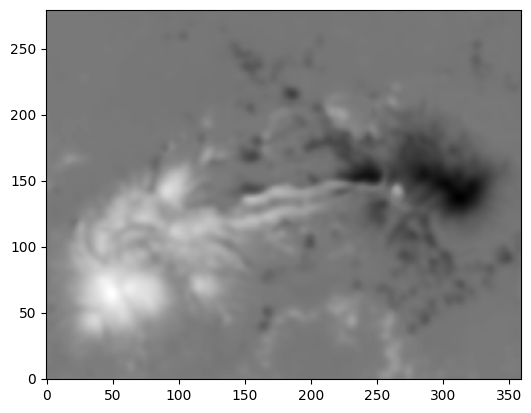

In [9]:
import amrvac_pytools as apt
import matplotlib.pyplot as plt
import numpy as np
ds = apt.load_datfile('C:/Users/19671/Desktop/0618/nlfff.dat')
ds.get_info()
ad = ds.load_all_data()
b1 = np.ascontiguousarray(ad['b1'])
b2 = np.ascontiguousarray(ad['b2'])
b3 = np.ascontiguousarray(ad['b3'])
plt.imshow(b3[:,:,0].T,origin='lower',cmap='grey')

In [10]:
pip install meshio

   ---------------------------------------- 0.0/166.2 kB ? eta -:--:--
   -- ------------------------------------- 10.2/166.2 kB ? eta -:--:--
   ------- ------------------------------- 30.7/166.2 kB 660.6 kB/s eta 0:00:01
   -------------- ------------------------ 61.4/166.2 kB 550.5 kB/s eta 0:00:01
   ----------------------- -------------- 102.4/166.2 kB 737.3 kB/s eta 0:00:01
   -------------------------------------- 166.2/166.2 kB 833.8 kB/s eta 0:00:00
   ---------------------------------------- 0.0/243.2 kB ? eta -:--:--
   -------------------- ------------------- 122.9/243.2 kB 7.5 MB/s eta 0:00:01
   ----------------------- ---------------- 143.4/243.2 kB 1.4 MB/s eta 0:00:01
   ---------------------------------------- 243.2/243.2 kB 2.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/87.5 kB ? eta -:--:--
   ---------------------------------------- 87.5/87.5 kB 4.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# 使用meshio库的替代方案
import meshio

points = np.array(np.meshgrid(
    np.arange(q3d.shape[0]),
    np.arange(q3d.shape[1]),
    np.arange(q3d.shape[2]),
    indexing='ij'
)).T.reshape(-1, 3)

cells = [("voxel", np.arange(q3d.size).reshape(-1, 8))]  # 简化处理
meshio.write_points_cells(
    "output.vtu",
    points,
    cells,
    point_data={"values": q3d.flatten()}
)